# Fibonacci Lattice

In [104]:
import math


def fibonacci_sphere(samples=1000):

    points = []
    phi = math.pi * (math.sqrt(5.) - 1.)  # golden angle in radians

    for i in range(samples):
        z = 1 - (i / float(samples - 1)) * 2  # z goes from 1 to -1
        radius = math.sqrt(1 - z * z)  # radius at z

        theta = phi * i  # golden angle increment

        x = math.cos(theta) * radius
        y = math.sin(theta) * radius

        points.append((x, y, z))

    return points

In [107]:
import torch

BASELINE = 50 # for 5 it and the lattice is 0-sPSS, not sure how to prove that it will hold for arbitrary k... yep, 2*k fails for baseline=5 and k=2

k = 2
points = torch.tensor(fibonacci_sphere(BASELINE + 2*k))
print(points)

tensor([[ 0.0000,  0.0000,  1.0000],
        [-0.2007, -0.1838,  0.9623],
        [ 0.0333,  0.3797,  0.9245],
        [ 0.2812, -0.3668,  0.8868],
        [-0.5202,  0.0920,  0.8491],
        [ 0.4933,  0.3138,  0.8113],
        [-0.1645, -0.6120,  0.7736],
        [-0.3121,  0.6009,  0.7358],
        [ 0.6725, -0.2456,  0.6981],
        [-0.6941, -0.2865,  0.6604],
        [ 0.3317,  0.7087,  0.6226],
        [ 0.2427, -0.7739,  0.5849],
        [-0.7242,  0.4197,  0.5472],
        [ 0.8404,  0.1848,  0.5094],
        [-0.5071, -0.7213,  0.4717],
        [-0.1158,  0.8935,  0.4340],
        [ 0.7021, -0.5917,  0.3962],
        [-0.9327, -0.0386,  0.3585],
        [ 0.6714,  0.6681,  0.3208],
        [-0.0443, -0.9581,  0.2830],
        [-0.6211,  0.7443,  0.2453],
        [ 0.9695, -0.1304,  0.2075],
        [-0.8089, -0.5628,  0.1698],
        [ 0.2176,  0.9671,  0.1321],
        [ 0.4950, -0.8638,  0.0943],
        [-0.9512,  0.3034,  0.0566],
        [ 0.9076,  0.4193,  0.0189],
 

In [64]:
points = torch.tensor([[ 0.0000,  0.0000,  1.0000],
        [-0.4877, -0.4468,  0.7500],
        [ 0.0757,  0.8627,  0.5000],
        # [ 0.5891, -0.7684,  0.2500],
        [-0.9847,  0.1742,  0.0000],
        # [ 0.8170,  0.5197, -0.2500],
        [-0.2248, -0.8363, -0.5000],
        [-0.3049,  0.5870, -0.7500],
        [ 0.0000, -0.0000, -1.0000]])

In [65]:
# testing for baseline using NEM matrix
from sympy import Matrix
import numpy as np

rref_matrix, pivot_cols = Matrix(points.T.numpy()).rref()
np.array(rref_matrix)[:, 3:]

array([[-2.35058, -0.355935, -1.89200, -1.00000],
       [2.22965, 0.337611, 0.794677, 0],
       [1.35668, -0.794547, 1.09199, 0]], dtype=object)

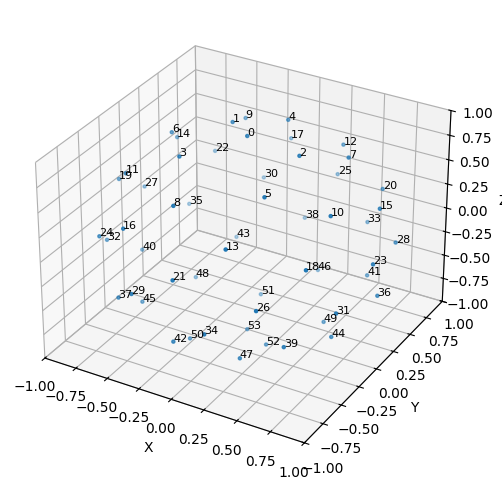

In [108]:
import torch
import matplotlib.pyplot as plt
import time
import math
from IPython.display import display, clear_output

# Rotation matrix around Z axis
def rotate_z(points, angle):
    c = math.cos(angle)
    s = math.sin(angle)
    R = torch.tensor([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])
    return points @ R.T

# Control variable for labels
show_labels = True  # Set to False to hide labels

angle = 0.0
for _ in range(100):  # limit iterations instead of while True
    clear_output(wait=True)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    
    rotated = rotate_z(points, angle)
    ax.scatter(
        rotated[:, 0].numpy(),
        rotated[:, 1].numpy(),
        rotated[:, 2].numpy(),
        s=5
    )
    
    # Add labels if enabled
    if show_labels:
        for i in range(len(rotated)):
            ax.text(
                rotated[i, 0].item(),
                rotated[i, 1].item(),
                rotated[i, 2].item(),
                str(i),
                fontsize=8
            )
    
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    plt.show()
    plt.close(fig)
    
    time.sleep(0.1)
    angle += math.pi / 64  # rotation step

In [ ]:

points.T

tensor([[ 0.0000, -0.6952,  0.0824,  0.0000],
        [ 0.0000, -0.6369,  0.9392, -0.0000],
        [ 1.0000,  0.3333, -0.3333, -1.0000]])

Matrix([
[1, 0, 0, -1.0],
[0, 1, 0,    0],
[0, 0, 1,    0]])

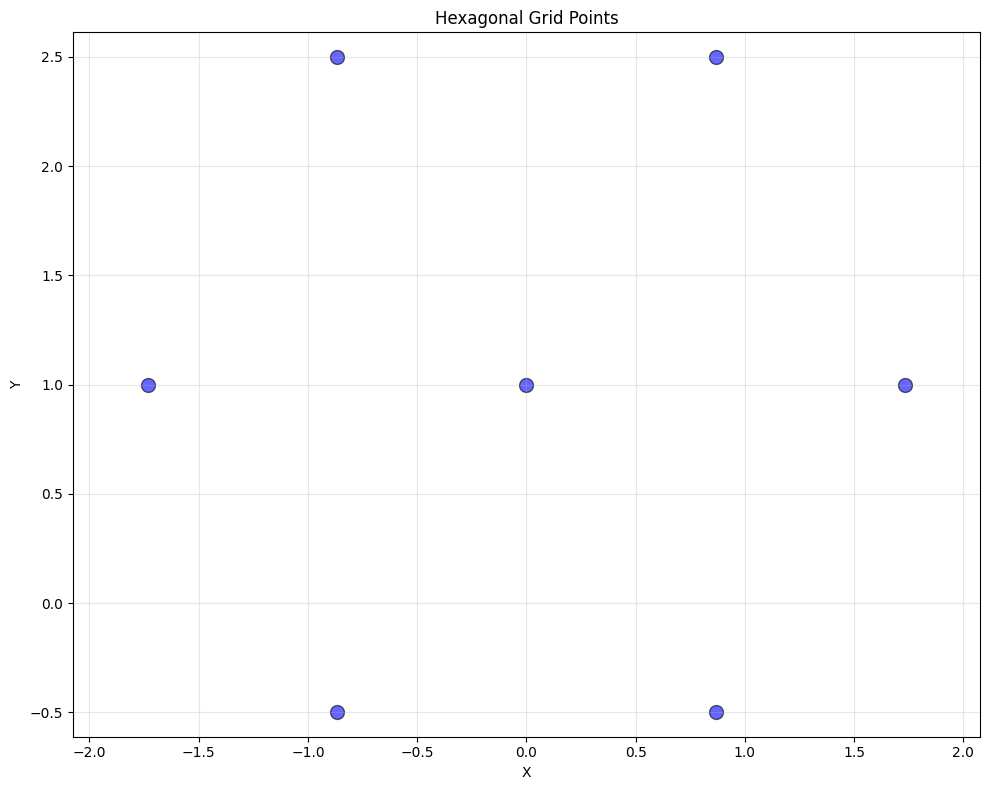

In [90]:
points = []
spacing = 1
r = 1

for row in range(-r, r+1):
    for col in range(-r, r+1):
        if row == r and col % 2 == 1:
            continue

        # Horizontal spacing
        y = col * spacing * 1.5 + 1
        
        # Vertical spacing with offset for odd columns
        x = row * spacing * math.sqrt(3)
        if col % 2 == 1:
            x += spacing * math.sqrt(3) / 2
        
        points.append((x, y))



x_coords = [p[0] for p in points]
y_coords = [p[1] for p in points]

# Create the plot
plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, s=100, c='blue', alpha=0.6, edgecolors='black')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.title('Hexagonal Grid Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

In [ ]:
def hex_grid(spacing, r): # TODO rewrite and delete
    points = []

    for row in range(-r, r+1, 1):
        for col in range(-r, r+1, 1):
            if row == r and col % 2 == 1:
                continue

            # Horizontal spacing
            y = col * spacing * 1.5 + 1
            
            # Vertical spacing with offset for odd columns
            x = row * spacing * math.sqrt(3)
            if col % 2 == 1:
                x += spacing * math.sqrt(3) / 2
            
            points.append((x, y))
        
        return points



delta_mesh = 1
delta = 1
# FOR THREE DIMENSIONS ONLY TODO: GENERALISE
# building the R^3 k-sPSS (idk how to name it but the thing i have in my notes)
b = 1.4142135624

steps = int(b * delta / delta_mesh)
print(steps)
points_list = hex_grid(delta_mesh, steps)

tensors = []
for z_offset in range(-steps, steps+1):
    t = torch.tensor(points_list)
    t = torch.cat((t, torch.zeros((t.shape[0], 1))), dim=1)
    t[:, 2] += z_offset * delta_mesh
    tensors.append(t)

P = torch.cat(tensors, dim=0)
print(P) # TODO: but different layers will have different offsets...

1
tensor([[-0.8660, -0.5000, -1.0000],
        [-1.7321,  1.0000, -1.0000],
        [-0.8660,  2.5000, -1.0000],
        [-0.8660, -0.5000,  0.0000],
        [-1.7321,  1.0000,  0.0000],
        [-0.8660,  2.5000,  0.0000],
        [-0.8660, -0.5000,  1.0000],
        [-1.7321,  1.0000,  1.0000],
        [-0.8660,  2.5000,  1.0000]])


In [36]:
import torch

num_points = 2 + 1 + 2*1

frame_expansion = (torch.ones(num_points, 1) * torch.arange(1, 2)).T
theta = torch.linspace(0, 2*torch.pi, num_points+1)[:-1]

D = torch.stack([(frame_expansion * torch.cos(theta)).reshape(-1), (frame_expansion * torch.sin(theta)).reshape(-1)], dim=1)
D

tensor([[ 1.0000,  0.0000],
        [ 0.3090,  0.9511],
        [-0.8090,  0.5878],
        [-0.8090, -0.5878],
        [ 0.3090, -0.9511]])

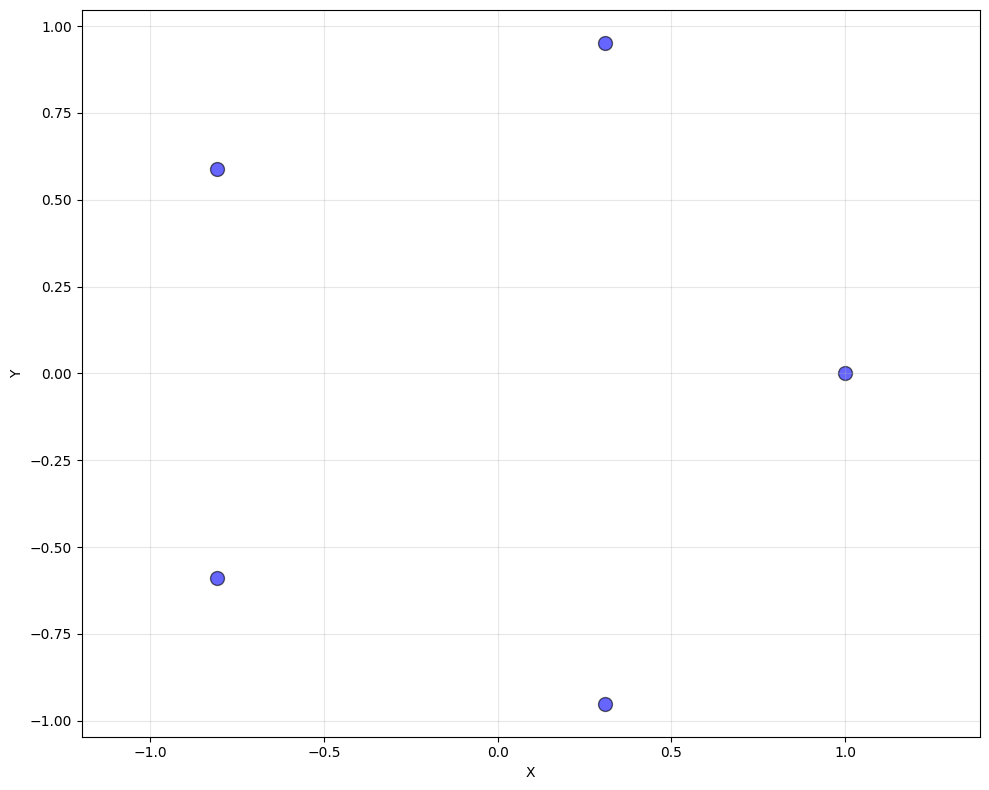

In [37]:
import matplotlib.pyplot as plt

x_coords = [p[0] for p in D]
y_coords = [p[1] for p in D]

# Create the plot
plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, s=100, c='blue', alpha=0.6, edgecolors='black')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

In [91]:
def get_k_spss_1d(k):
    D = torch.cat((torch.ones((k+1, 1)) * torch.tensor([-1], dtype=torch.float32), torch.ones((k+1, 1)) * torch.tensor([1], dtype=torch.float32)), dim=0)
    return D

def get_k_spss_2d(k):
    num_points = 2+1 + 2*k

    frame_expansion = (torch.ones(num_points, 1) * torch.arange(1, 2)).T
    theta = torch.linspace(0, 2*torch.pi, num_points+1)[:-1]

    D = torch.stack([(frame_expansion * torch.cos(theta)).reshape(-1), (frame_expansion * torch.sin(theta)).reshape(-1)], dim=1)
    return D

In [102]:
def select_k_spss(predicted_k_fail, num_dim):
    # slit into R2 orthogonal, add R1 if needed
    subspaces = []
    
    for i in range(num_dim//2):
        D2 = get_k_spss_2d(predicted_k_fail)
        orthogonal_subspace = torch.nn.functional.pad(D2, (i * 2, num_dim - 2 - i*2), "constant", 0)
        subspaces.append(orthogonal_subspace)
    if num_dim%2 == 1:
        # get R1 k-spss
        D1 = get_k_spss_1d(predicted_k_fail)
        orthogonal_subspace = torch.nn.functional.pad(D1, (num_dim-1, 0), "constant", 0)
        subspaces.append(orthogonal_subspace)
    print(subspaces)
    return torch.stack(subspaces, dim=1)

In [103]:
select_k_spss(0, 5)

[tensor([[ 1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.5000,  0.8660,  0.0000,  0.0000,  0.0000],
        [-0.5000, -0.8660,  0.0000,  0.0000,  0.0000]]), tensor([[ 0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.5000,  0.8660,  0.0000],
        [ 0.0000,  0.0000, -0.5000, -0.8660,  0.0000]]), tensor([[ 0.,  0.,  0.,  0., -1.],
        [ 0.,  0.,  0.,  0.,  1.]])]


RuntimeError: stack expects each tensor to be equal size, but got [3, 5] at entry 0 and [2, 5] at entry 2

In [85]:
torch.cat((torch.ones((2, 1)) * torch.tensor([-1], dtype=torch.float32), torch.ones((3, 1)) * torch.tensor([1], dtype=torch.float32)), dim=0)

tensor([[-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.]])